In [ ]:
from google.colab import files

uploaded=files.upload()

Saving clean_dataset.csv to clean_dataset (2).csv


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import numpy as np
import pandas as pd
df=pd.read_csv('clean_dataset.csv')

In [ ]:
df.head()

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1,1,Industrials,White,1.25,1,1,1,0,ByBirth,202,0,1
1,0,58.67,4.460,1,1,Materials,Black,3.04,1,1,6,0,ByBirth,43,560,1
2,0,24.50,0.500,1,1,Materials,Black,1.50,1,0,0,0,ByBirth,280,824,1
3,1,27.83,1.540,1,1,Industrials,White,3.75,1,1,5,1,ByBirth,100,3,1
4,1,20.17,5.625,1,1,Industrials,White,1.71,1,0,0,0,ByOtherMeans,120,0,1


In [ ]:
df.shape

(690, 16)

In [ ]:
df.describe()

,Gender,Age,Debt,Married,BankCustomer,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,ZipCode,Income,Approved
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000
mean,0.695652,31.514116,4.758725,0.760870,0.763768,2.223406,0.523188,0.427536,2.40000,0.457971,180.547826,1017.385507,0.444928
std,0.460464,11.860245,4.978163,0.426862,0.425074,3.346513,0.499824,0.495080,4.86294,0.498592,173.970323,5210.102598,0.497318
min,0.000000,13.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,22.670000,1.000000,1.000000,1.000000,0.165000,0.000000,0.000000,0.00000,0.000000,60.000000,0.000000,0.000000
50%,1.000000,28.460000,2.750000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,160.000000,5.000000,0.000000
75%,1.000000,37.707500,7.207500,1.000000,1.000000,2.625000,1.000000,1.000000,3.00000,1.000000,272.000000,395.500000,1.000000
max,1.000000,80.250000,28.000000,1.000000,1.000000,28.500000,1.000000,1.000000,67.00000,1.000000,2000.000000,100000.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Gender,0
Age,0
Debt,0
Married,0
BankCustomer,0
Industry,0
Ethnicity,0
YearsEmployed,0
PriorDefault,0
Employed,0


In [ ]:
df.dtypes

,0
Gender,int64
Age,float64
Debt,float64
Married,int64
BankCustomer,int64
Industry,object
Ethnicity,object
YearsEmployed,float64
PriorDefault,int64
Employed,int64


In [ ]:
df.columns=df.columns.str.lower()

In [ ]:
df.head()

,gender,age,debt,married,bankcustomer,industry,ethnicity,yearsemployed,priordefault,employed,creditscore,driverslicense,citizen,zipcode,income,approved
0,1,30.83,0.000,1,1,Industrials,White,1.25,1,1,1,0,ByBirth,202,0,1
1,0,58.67,4.460,1,1,Materials,Black,3.04,1,1,6,0,ByBirth,43,560,1
2,0,24.50,0.500,1,1,Materials,Black,1.50,1,0,0,0,ByBirth,280,824,1
3,1,27.83,1.540,1,1,Industrials,White,3.75,1,1,5,1,ByBirth,100,3,1
4,1,20.17,5.625,1,1,Industrials,White,1.71,1,0,0,0,ByOtherMeans,120,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          690 non-null    int64  
 1   age             690 non-null    float64
 2   debt            690 non-null    float64
 3   married         690 non-null    int64  
 4   bankcustomer    690 non-null    int64  
 5   industry        690 non-null    object 
 6   ethnicity       690 non-null    object 
 7   yearsemployed   690 non-null    float64
 8   priordefault    690 non-null    int64  
 9   employed        690 non-null    int64  
 10  creditscore     690 non-null    int64  
 11  driverslicense  690 non-null    int64  
 12  citizen         690 non-null    object 
 13  zipcode         690 non-null    int64  
 14  income          690 non-null    int64  
 15  approved        690 non-null    int64  
dtypes: float64(3), int64(10), object(3)
memory usage: 86.4+ KB


In [ ]:
df['approved'].value_counts()

,count
approved,
0,383
1,307


In [ ]:
df['approved'].value_counts(normalize=True)

,proportion
approved,
0,0.555072
1,0.444928


In [ ]:
# which industry have the highest avg debt

avg_debt=df.groupby('industry')['debt'].mean()
avg_debt.sort_values(ascending=False)

,debt
industry,
Education,8.208400
Utilities,6.081974
Healthcare,5.838019
Transport,5.596667
Materials,5.190577
ConsumerStaples,5.164259
Real Estate,4.786167
Research,4.667000
Industrials,4.569453


In [ ]:
# employeement vs debt carry less debt

min_debt=df.groupby('employed')['debt'].mean()
min_debt

,debt
employed,
0,4.007063
1,5.765186


In [ ]:
# highest debt with married or not married

married_debt=df.groupby('married')['debt'].mean()
married_debt.sort_values(ascending=False)

,debt
married,
1,4.966905
0,4.096333


In [ ]:
df=df.drop(columns=['married','ethnicity','citizen','zipcode'])

In [ ]:
df=pd.get_dummies(df,drop_first=True)

In [ ]:
df.shape

(690, 24)

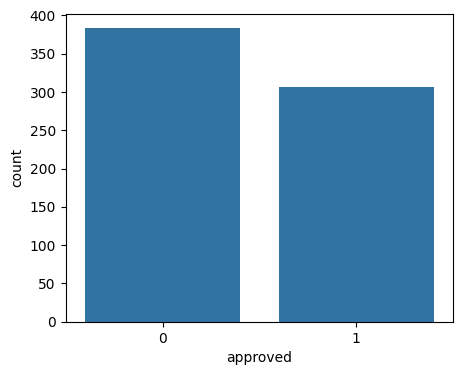

In [ ]:
# graph
# target distribution

plt.figure(figsize=(5,4))
sns.countplot(x='approved',data=df)
plt.show()

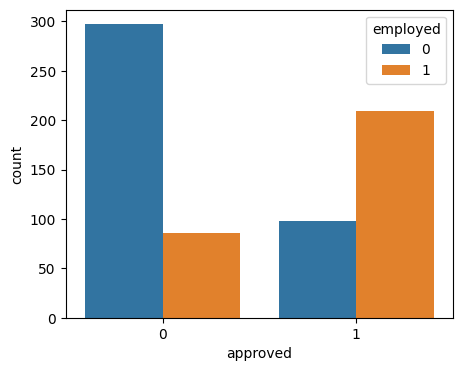

In [ ]:
# compare credit card approved or rejected

plt.figure(figsize=(5,4))
sns.countplot(x='approved',hue='employed',data=df)
plt.show()

In [ ]:
df.corr()

,gender,age,debt,bankcustomer,yearsemployed,priordefault,employed,creditscore,driverslicense,income,...,industry_Energy,industry_Financials,industry_Healthcare,industry_Industrials,industry_InformationTechnology,industry_Materials,industry_Real Estate,industry_Research,industry_Transport,industry_Utilities
gender,1.000000,0.035044,-0.041746,-0.071250,0.086544,-0.026047,-0.077784,-0.024630,0.051674,-0.002063,...,0.080469,0.054436,-0.116737,0.102913,0.033018,-0.221431,0.063794,-0.156985,0.043709,0.007804
age,0.035044,1.000000,0.202177,0.099477,0.391464,0.204434,0.086037,0.187327,0.053599,0.018719,...,-0.058879,-0.004216,0.166759,-0.047101,-0.025805,-0.061783,-0.017769,-0.000902,-0.009669,0.006971
debt,-0.041746,0.202177,1.000000,0.083781,0.298902,0.244317,0.174846,0.271207,-0.013023,0.123121,...,-0.058340,-0.042265,0.062583,-0.012166,-0.036943,0.030992,0.001176,-0.002236,0.011131,0.064218
bankcustomer,-0.071250,0.099477,0.083781,1.000000,0.075905,0.138535,0.170268,0.111077,-0.002402,0.057273,...,-0.020969,-0.064582,-0.070210,0.013160,0.009893,0.133894,0.001455,-0.075304,-0.015106,-0.000347
yearsemployed,0.086544,0.391464,0.298902,0.075905,1.000000,0.345689,0.222982,0.322330,0.138139,0.051345,...,-0.005610,-0.058563,-0.077599,-0.008729,0.060111,0.045672,0.008507,-0.079577,0.039224,0.062229
priordefault,-0.026047,0.204434,0.244317,0.138535,0.345689,1.000000,0.432032,0.379532,0.091276,0.090012,...,-0.024052,-0.074115,-0.171392,0.025166,0.092659,0.157537,-0.081042,-0.029910,0.018983,0.154150
employed,-0.077784,0.086037,0.174846,0.170268,0.222982,0.432032,1.000000,0.571498,0.017043,0.077652,...,-0.003014,-0.076189,0.003747,0.046834,0.055403,0.154059,-0.126787,-0.031262,-0.012583,0.099570
creditscore,-0.024630,0.187327,0.271207,0.111077,0.322330,0.379532,0.571498,1.000000,0.006944,0.063692,...,0.028186,-0.054033,-0.040543,-0.015010,0.121865,0.078929,-0.046799,0.007487,0.008159,0.018042
driverslicense,0.051674,0.053599,-0.013023,-0.002402,0.138139,0.091276,0.017043,0.006944,1.000000,0.019201,...,-0.041761,0.029391,-0.112211,0.037000,0.002746,0.002556,0.060776,-0.038450,0.071891,0.020365
income,-0.002063,0.018719,0.123121,0.057273,0.051345,0.090012,0.077652,0.063692,0.019201,1.000000,...,-0.023532,-0.026435,0.073808,-0.023613,0.043967,-0.001167,-0.037106,-0.020222,0.120025,0.003599


In [ ]:
# feature and target seperation

x=df.drop(columns=['approved'])
y=df['approved']

In [ ]:
# train and test split

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
x_train.shape

(552, 23)

In [ ]:
x_test.shape

(138, 23)

In [ ]:
y_train.shape

(552,)

In [ ]:
df['approved'].value_counts(normalize=True)

,proportion
approved,
0,0.555072
1,0.444928


In [ ]:
y_train.value_counts(normalize=True)

,proportion
approved,
0,0.554348
1,0.445652


In [ ]:
y_test.value_counts(normalize=True)

,proportion
approved,
0,0.557971
1,0.442029


In [ ]:
# feature scaling

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
#prediction
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

In [ ]:
# evaluation part

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print('train acc:',accuracy_score(y_train,y_pred_train))
print('test acc:',accuracy_score(y_test,y_pred_test))

train acc: 1.0
test acc: 0.8913043478260869


In [ ]:
cm=confusion_matrix(y_test,y_pred_test)
cm

array([[69,  8],
       [12, 49]])

In [ ]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87        77
           1       0.86      0.80      0.83        61

    accuracy                           0.86       138
   macro avg       0.86      0.85      0.85       138
weighted avg       0.86      0.86      0.85       138



In [ ]:
# decision tree

from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
#prediction
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

In [ ]:
# evaluation part

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print('train acc:',accuracy_score(y_train,y_pred_train))
print('test acc:',accuracy_score(y_test,y_pred_test))

train acc: 1.0
test acc: 0.8913043478260869


In [ ]:
cm=confusion_matrix(y_test,y_pred_test)
cm

array([[64, 13],
       [ 9, 52]])

In [ ]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.88      0.83      0.85        77
           1       0.80      0.85      0.83        61

    accuracy                           0.84       138
   macro avg       0.84      0.84      0.84       138
weighted avg       0.84      0.84      0.84       138



In [ ]:
# random forest

from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
# predict

y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

In [ ]:
# evaluation

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print('train acc:',accuracy_score(y_train,y_pred_train))
print('test acc:',accuracy_score(y_test,y_pred_test))

train acc: 1.0
test acc: 0.8913043478260869


In [ ]:
# confusion matrix

cm=confusion_matrix(y_test,y_pred_test)
cm

array([[72,  5],
       [10, 51]])

In [ ]:
# classification report

print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91        77
           1       0.91      0.84      0.87        61

    accuracy                           0.89       138
   macro avg       0.89      0.89      0.89       138
weighted avg       0.89      0.89      0.89       138

